# Survival Analysis of Clinical Outcomes

## Objective

Evaluate time-to-event outcomes in the fictional TRIDENT-201 Phase II 
oncology trial while appropriately accounting for events, censoring, 
follow-up time, and endpoint-specific data quality.

## Initial biological questions

1. Does TRIDENT + SOC prolong progression-free survival compared with SOC?
2. Are baseline biomarkers associated with progression or death?
3. Do any baseline biomarkers have different survival associations between 
   the treatment arms?

## Analysis principles

- Preserve the original clinical dataset.
- Verify survival-variable definitions and event encoding before analysis.
- Perform endpoint-specific quality control.
- Do not silently correct or remove impossible values.
- Interpret effect size, uncertainty, statistical evidence, and biological 
  meaning—in that order.

In [1]:
# Objective: Define the project and clinical-data paths and confirm the file exists.

from pathlib import Path

# Define the main repository location.
PROJECT_ROOT = Path(
    "/Users/goncabulbul/Documents/GitHub/"
    "TRIDENT-201-translational-analysis"
)

# Point to the original clinical dataset without modifying it.
clinical_file_path = PROJECT_ROOT / "data" / "raw" / "clinical.csv"

# Display the path and confirm that Python can find the file.
print("Clinical data path:", clinical_file_path)
print("Clinical file exists:", clinical_file_path.exists())

Clinical data path: /Users/goncabulbul/Documents/GitHub/TRIDENT-201-translational-analysis/data/raw/clinical.csv
Clinical file exists: True


In [2]:
# Objective: Load the original clinical data and create a separate survival working copy.

import pandas as pd

# Load the original data into memory.
# We will treat this object as read-only.
clinical_original = pd.read_csv(clinical_file_path)

# Create an independent copy for survival-data inspection and later QC.
survival_working = clinical_original.copy()

# Confirm the number of rows and columns.
print("Original clinical data shape:", clinical_original.shape)
print("Survival working copy shape:", survival_working.shape)

# Display every available column name.
print("\nAvailable clinical columns:")
for column_name in clinical_original.columns:
    print("-", column_name)

Original clinical data shape: (251, 15)
Survival working copy shape: (251, 15)

Available clinical columns:
- patient_id
- treatment_arm
- age
- sex
- disease_stage
- ecog_status
- smoking_status
- histology
- best_overall_response
- pfs_days
- pfs_event
- os_days
- os_event
- study_site
- enrollment_date


In [3]:
# Objective: Inspect survival-variable types, event values, and example records.

# List the survival variables identified from the actual dataset.
survival_columns = [
    "patient_id",
    "pfs_days",
    "pfs_event",
    "os_days",
    "os_event",
]

# Display the data type assigned to each survival variable.
print("Survival-variable data types:")
print(survival_working[survival_columns].dtypes)

# Count every observed PFS event-indicator value, including missing values.
print("\nPFS event values and counts:")
print(
    survival_working["pfs_event"]
    .value_counts(dropna=False)
    .sort_index()
)

# Count every observed OS event-indicator value, including missing values.
print("\nOS event values and counts:")
print(
    survival_working["os_event"]
    .value_counts(dropna=False)
    .sort_index()
)

# Display a small sample with time and event information paired together.
print("\nFirst 10 survival records:")
display(survival_working[survival_columns].head(10))

Survival-variable data types:
patient_id    object
pfs_days       int64
pfs_event      int64
os_days        int64
os_event       int64
dtype: object

PFS event values and counts:
pfs_event
0     68
1    183
Name: count, dtype: int64

OS event values and counts:
os_event
0    127
1    124
Name: count, dtype: int64

First 10 survival records:


,patient_id,pfs_days,pfs_event,os_days,os_event
0,TRI-001,323,1,323,1
1,TRI-002,20,1,126,0
2,TRI-003,159,0,363,1
3,TRI-004,328,0,548,0
4,TRI-005,425,1,474,0
5,TRI-006,203,1,275,1
6,TRI-007,220,1,512,1
7,TRI-008,20,1,214,0
8,TRI-009,207,1,670,0
9,TRI-010,85,1,285,1


In [4]:
# Objective: Audit PFS and OS times for missing, zero, negative, and extreme values.

# Summarize the basic validity checks separately for PFS and OS.
survival_time_qc = pd.DataFrame(
    {
        "PFS": {
            "missing_times": survival_working["pfs_days"].isna().sum(),
            "zero_times": (survival_working["pfs_days"] == 0).sum(),
            "negative_times": (survival_working["pfs_days"] < 0).sum(),
            "minimum_time": survival_working["pfs_days"].min(),
            "maximum_time": survival_working["pfs_days"].max(),
        },
        "OS": {
            "missing_times": survival_working["os_days"].isna().sum(),
            "zero_times": (survival_working["os_days"] == 0).sum(),
            "negative_times": (survival_working["os_days"] < 0).sum(),
            "minimum_time": survival_working["os_days"].min(),
            "maximum_time": survival_working["os_days"].max(),
        },
    }
)

display(survival_time_qc)

# Display any patients with nonpositive PFS or OS times.
nonpositive_survival_records = survival_working.loc[
    (survival_working["pfs_days"] <= 0)
    | (survival_working["os_days"] <= 0),
    survival_columns,
]

print("Patients with a nonpositive survival time:")
display(nonpositive_survival_records)

,PFS,OS
missing_times,0,0
zero_times,0,0
negative_times,1,0
minimum_time,-14,28
maximum_time,549,915


Patients with a nonpositive survival time:


,patient_id,pfs_days,pfs_event,os_days,os_event
137,TRI-138,-14,1,347,0


In [5]:
# Objective: Identify duplicated patient IDs and inspect all associated records.

# Count the total rows and number of unique patients.
print("Total clinical rows:", len(survival_working))
print("Unique patient IDs:", survival_working["patient_id"].nunique())

# Identify every patient ID occurring more than once.
duplicate_id_counts = (
    survival_working["patient_id"]
    .value_counts()
    .loc[lambda counts: counts > 1]
)

print("\nDuplicated patient IDs and row counts:")
display(duplicate_id_counts)

# Retrieve the complete records for all duplicated patient IDs.
duplicate_patient_records = (
    survival_working.loc[
        survival_working["patient_id"].isin(duplicate_id_counts.index)
    ]
    .sort_values("patient_id")
)

print("\nComplete duplicated patient records:")
display(duplicate_patient_records)

Total clinical rows: 251
Unique patient IDs: 250

Duplicated patient IDs and row counts:


patient_id
TRI-075    2
Name: count, dtype: int64


Complete duplicated patient records:


,patient_id,treatment_arm,age,sex,disease_stage,ecog_status,smoking_status,histology,best_overall_response,pfs_days,pfs_event,os_days,os_event,study_site,enrollment_date
74,TRI-075,TRIDENT + SOC,47,Male,IV,1,Current,Adenocarcinoma,PR,279,1,492,1,SITE-07,2024-02-06
250,TRI-075,TRIDENT + SOC,47,Male,IV,1,Current,Adenocarcinoma,PR,279,1,492,1,SITE-07,2024-02-06


In [6]:
# Objective: Create a patient-level dataset by removing exact duplicate rows only.

# Remove rows that are identical across every clinical column.
# Keep the first occurrence and preserve survival_working unchanged.
survival_patient_level = (
    survival_working
    .drop_duplicates(keep="first")
    .copy()
)

# Confirm the result.
print("Rows before removing exact duplicates:", len(survival_working))
print("Rows after removing exact duplicates:", len(survival_patient_level))
print(
    "Unique patients after removing duplicates:",
    survival_patient_level["patient_id"].nunique()
)

# Confirm that no patient IDs remain duplicated.
print(
    "Remaining duplicated patient IDs:",
    survival_patient_level["patient_id"].duplicated().sum()
)

Rows before removing exact duplicates: 251
Rows after removing exact duplicates: 250
Unique patients after removing duplicates: 250
Remaining duplicated patient IDs: 0


In [7]:
# Objective: Identify records where PFS time is greater than OS time.

# Create a Boolean indicator for inconsistent endpoint ordering.
pfs_exceeds_os = (
    survival_patient_level["pfs_days"]
    > survival_patient_level["os_days"]
)

# Retrieve the affected patient records.
pfs_os_order_inconsistencies = survival_patient_level.loc[
    pfs_exceeds_os,
    survival_columns,
]

print(
    "Number of patients with PFS time greater than OS time:",
    pfs_exceeds_os.sum()
)

print("\nRecords with PFS time greater than OS time:")
display(pfs_os_order_inconsistencies)

Number of patients with PFS time greater than OS time: 0

Records with PFS time greater than OS time:


,patient_id,pfs_days,pfs_event,os_days,os_event


In [8]:
# Objective: Create separate PFS and OS analysis populations using explicit validity rules.

# Define the PFS validity rule.
# Valid PFS records must have nonmissing time and event values and time above zero.
pfs_valid_record = (
    survival_patient_level["pfs_days"].notna()
    & survival_patient_level["pfs_event"].notna()
    & (survival_patient_level["pfs_days"] > 0)
)

# Record excluded PFS patients and the reason before filtering.
pfs_exclusion_log = survival_patient_level.loc[
    ~pfs_valid_record,
    survival_columns,
].copy()

pfs_exclusion_log["exclusion_reason"] = (
    "Invalid nonpositive PFS time"
)

# Create the PFS analysis population.
pfs_analysis_data = survival_patient_level.loc[
    pfs_valid_record
].copy()

# Create the OS analysis population using its endpoint-specific validity rules.
os_analysis_data = survival_patient_level.loc[
    survival_patient_level["os_days"].notna()
    & survival_patient_level["os_event"].notna()
    & (survival_patient_level["os_days"] > 0)
].copy()

print("Patient-level population:", len(survival_patient_level))
print("PFS analysis population:", len(pfs_analysis_data))
print("OS analysis population:", len(os_analysis_data))

print("\nPFS exclusion log:")
display(pfs_exclusion_log)

Patient-level population: 250
PFS analysis population: 249
OS analysis population: 250

PFS exclusion log:


,patient_id,pfs_days,pfs_event,os_days,os_event,exclusion_reason
137,TRI-138,-14,1,347,0,Invalid nonpositive PFS time


## 8. Describe the endpoint-specific populations

### Objective

Confirm the treatment-arm labels and summarize patient and event counts for the 
PFS and OS analysis populations.

### Biological hypothesis

The later treatment hypothesis will be that TRIDENT + SOC improves survival relative 
to SOC. This descriptive step does not test that hypothesis.

In [9]:
# Objective: Summarize treatment-arm sizes and event counts for PFS and OS.

# Summarize the PFS population by treatment arm.
pfs_population_summary = (
    pfs_analysis_data
    .groupby("treatment_arm")
    .agg(
        patients=("patient_id", "nunique"),
        pfs_events=("pfs_event", "sum"),
        pfs_censored=("pfs_event", lambda values: (values == 0).sum()),
    )
    .reset_index()
)

# Summarize the OS population by treatment arm.
os_population_summary = (
    os_analysis_data
    .groupby("treatment_arm")
    .agg(
        patients=("patient_id", "nunique"),
        os_events=("os_event", "sum"),
        os_censored=("os_event", lambda values: (values == 0).sum()),
    )
    .reset_index()
)

print("PFS population summary:")
display(pfs_population_summary)

print("\nOS population summary:")
display(os_population_summary)

PFS population summary:


,treatment_arm,patients,pfs_events,pfs_censored
0,SOC,124,95,29
1,TRIDENT + SOC,124,85,39
2,Trident + SOC,1,1,0



OS population summary:


,treatment_arm,patients,os_events,os_censored
0,SOC,125,59,66
1,TRIDENT + SOC,124,64,60
2,Trident + SOC,1,0,1


In [10]:
# Objective: Identify the patient with the inconsistently capitalized treatment label.

# Display every treatment label exactly as stored and its frequency.
treatment_label_counts = (
    survival_patient_level["treatment_arm"]
    .value_counts(dropna=False)
)

print("Treatment labels in the patient-level dataset:")
display(treatment_label_counts)

# Retrieve the complete record using the variant capitalization.
treatment_label_variant_record = survival_patient_level.loc[
    survival_patient_level["treatment_arm"] == "Trident + SOC"
].copy()

print("\nRecord with the variant treatment label:")
display(treatment_label_variant_record)

Treatment labels in the patient-level dataset:


treatment_arm
SOC              125
TRIDENT + SOC    124
Trident + SOC      1
Name: count, dtype: int64


Record with the variant treatment label:


,patient_id,treatment_arm,age,sex,disease_stage,ecog_status,smoking_status,histology,best_overall_response,pfs_days,pfs_event,os_days,os_event,study_site,enrollment_date
198,TRI-199,Trident + SOC,47,Male,IV,2,Current,Adenocarcinoma,SD,335,1,491,0,SITE-05,2024-06-08


In [11]:
# Objective: Standardize the treatment label in the endpoint-specific datasets.

# Document the category-label correction.
treatment_label_map = {
    "Trident + SOC": "TRIDENT + SOC"
}

# Standardize the label in the PFS analysis dataset.
pfs_analysis_data["treatment_arm"] = (
    pfs_analysis_data["treatment_arm"]
    .replace(treatment_label_map)
)

# Standardize the label in the OS analysis dataset.
os_analysis_data["treatment_arm"] = (
    os_analysis_data["treatment_arm"]
    .replace(treatment_label_map)
)

# Confirm that only the two intended treatment arms remain.
print("PFS treatment-arm counts:")
print(pfs_analysis_data["treatment_arm"].value_counts())

print("\nOS treatment-arm counts:")
print(os_analysis_data["treatment_arm"].value_counts())

PFS treatment-arm counts:
treatment_arm
TRIDENT + SOC    125
SOC              124
Name: count, dtype: int64

OS treatment-arm counts:
treatment_arm
TRIDENT + SOC    125
SOC              125
Name: count, dtype: int64


# Objective: Recalculate PFS and OS event summaries after treatment-label standardization.

# Recalculate the PFS population summary.
pfs_population_summary = (
    pfs_analysis_data
    .groupby("treatment_arm")
    .agg(
        patients=("patient_id", "nunique"),
        pfs_events=("pfs_event", "sum"),
        pfs_censored=("pfs_event", lambda values: (values == 0).sum()),
    )
    .reset_index()
)

# Recalculate the OS population summary.
os_population_summary = (
    os_analysis_data
    .groupby("treatment_arm")
    .agg(
        patients=("patient_id", "nunique"),
        os_events=("os_event", "sum"),
        os_censored=("os_event", lambda values: (values == 0).sum()),
    )
    .reset_index()
)

print("Corrected PFS population summary:")
display(pfs_population_summary)

print("\nCorrected OS population summary:")
display(os_population_summary)

In [12]:
# Objective: Confirm that the lifelines survival-analysis package is installed.

try:
    # Import the package used for survival analysis.
    import lifelines

    # Import the Kaplan–Meier estimator.
    from lifelines import KaplanMeierFitter

    print("lifelines version:", lifelines.__version__)
    print("KaplanMeierFitter imported successfully.")

except ModuleNotFoundError:
    print("lifelines is not installed in the current Python environment.")

lifelines version: 0.30.3
KaplanMeierFitter imported successfully.


In [13]:
# Objective: Install lifelines into the Python environment used by this notebook.

# %pip installs the package into the environment connected to the current kernel.
%pip install lifelines

Note: you may need to restart the kernel to use updated packages.


In [14]:
# Objective: Confirm that lifelines is now available.

import lifelines
from lifelines import KaplanMeierFitter

print("lifelines version:", lifelines.__version__)
print("KaplanMeierFitter imported successfully.")

lifelines version: 0.30.3
KaplanMeierFitter imported successfully.


### Worked Kaplan–Meier example

#### Objective

Use the five-patient example to connect the manual Kaplan–Meier calculation with 
the output produced by Python.

#### Biological hypothesis

This educational example does not test a treatment hypothesis.

In [15]:
# Objective: Fit a Kaplan–Meier estimator to the five-patient example.

# Create the small example dataset.
toy_survival_data = pd.DataFrame(
    {
        "patient": ["A", "B", "C", "D", "E"],
        "time_months": [2, 4, 5, 7, 8],
        "event": [1, 0, 1, 1, 0],
    }
)

# Create an unfitted Kaplan–Meier estimator.
toy_km = KaplanMeierFitter()

# Fit it using both observed time and event status.
toy_km.fit(
    durations=toy_survival_data["time_months"],
    event_observed=toy_survival_data["event"],
    label="Toy PFS",
)

# Display the calculated survival probabilities.
print("Kaplan–Meier survival estimates:")
display(toy_km.survival_function_)

Kaplan–Meier survival estimates:


,Toy PFS
timeline,
0.0,1.000000
2.0,0.800000
4.0,0.800000
5.0,0.533333
7.0,0.266667
8.0,0.266667


In [16]:
# Objective: Inspect the risk sets, events, and censoring used in the toy estimate.

# Display the internal event table created by KaplanMeierFitter.
toy_event_table = toy_km.event_table.copy()

display(toy_event_table)

,removed,observed,censored,entrance,at_risk
event_at,,,,,
0.0,0,0,0,5,5
2.0,1,1,0,0,5
4.0,1,0,1,0,4
5.0,1,1,0,0,3
7.0,1,1,0,0,2
8.0,1,0,1,0,1


In [17]:
# Objective: Retrieve the Kaplan–Meier median survival time for the toy example.

toy_median_survival = toy_km.median_survival_time_

print(
    "Toy Kaplan–Meier median survival:",
    toy_median_survival,
    "months"
)

Toy Kaplan–Meier median survival: 7.0 months


 ## 11. Overall progression-free survival

### Objective

Estimate progression-free survival across the complete valid PFS analysis 
population before comparing treatment arms.

### Biological question

How long do patients in the overall TRIDENT-201 population remain alive and 
free from disease progression?

### Statistical hypothesis

No between-group hypothesis is tested in this overall descriptive analysis.

In [18]:
# Objective: Fit the overall Kaplan–Meier estimator for progression-free survival.

# Create an unfitted Kaplan–Meier estimator for overall PFS.
pfs_km_overall = KaplanMeierFitter()

# Fit the estimator using valid PFS time and event status.
pfs_km_overall.fit(
    durations=pfs_analysis_data["pfs_days"],
    event_observed=pfs_analysis_data["pfs_event"],
    label="Overall PFS",
)

# Retrieve the estimated median PFS in days.
overall_median_pfs_days = pfs_km_overall.median_survival_time_

print("PFS analysis population:", len(pfs_analysis_data))
print("Observed PFS events:", int(pfs_analysis_data["pfs_event"].sum()))
print("Censored PFS observations:", int((pfs_analysis_data["pfs_event"] == 0).sum()))
print("Estimated median PFS:", overall_median_pfs_days, "days")

PFS analysis population: 249
Observed PFS events: 181
Censored PFS observations: 68
Estimated median PFS: 292.0 days


In [19]:
# Objective: Calculate the 95% confidence interval for overall median PFS.

# Import the utility that converts survival-curve confidence limits
# into confidence limits for median survival.
from lifelines.utils import median_survival_times

# Calculate the median PFS confidence interval.
overall_median_pfs_ci = median_survival_times(
    pfs_km_overall.confidence_interval_
)

print("Estimated median PFS:", overall_median_pfs_days, "days")
print("\n95% confidence interval for median PFS:")
display(overall_median_pfs_ci)

Estimated median PFS: 292.0 days

95% confidence interval for median PFS:


,Overall PFS_lower_0.95,Overall PFS_upper_0.95
0.5,277.0,302.0


### Overall PFS Kaplan–Meier curve

#### Objective

Visualize the estimated probability of remaining alive and progression-free over 
time, together with censoring marks and the 95% confidence interval.

#### Biological question

How does progression-free survival change over follow-up in the overall valid 
PFS population?

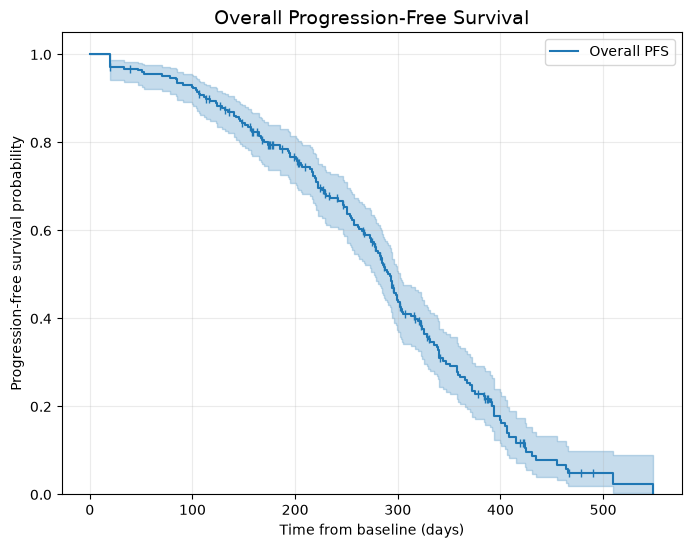

In [20]:
# Objective: Plot the overall PFS Kaplan–Meier curve with uncertainty and censoring.

import matplotlib.pyplot as plt

# Plot the fitted overall PFS estimator.
# Use "ms" rather than "markersize" to avoid a Matplotlib alias conflict.
pfs_overall_ax = pfs_km_overall.plot_survival_function(
    ci_show=True,
    show_censors=True,
    censor_styles={
        "marker": "|",
        "ms": 6,
    },
    figsize=(8, 6),
)

# Add clear scientific labels.
pfs_overall_ax.set_title(
    "Overall Progression-Free Survival",
    fontsize=14,
)

pfs_overall_ax.set_xlabel("Time from baseline (days)")
pfs_overall_ax.set_ylabel("Progression-free survival probability")

# Survival probabilities must remain between 0 and 1.
pfs_overall_ax.set_ylim(0, 1.05)

# Add a light reference grid.
pfs_overall_ax.grid(alpha=0.25)

plt.show()

### Landmark PFS probabilities

#### Objective

Estimate the probability of remaining alive and progression-free at approximately 
6 and 12 months in the overall PFS population.

#### Biological question

What proportion of the overall study population is estimated to remain alive and 
progression-free at 180 and 365 days?

In [21]:
# Objective: Estimate overall PFS probabilities and 95% CIs at 180 and 365 days.

# Define clinically interpretable landmark times.
pfs_landmark_days = [180, 365]

# Retrieve the Kaplan–Meier point estimates.
overall_pfs_landmarks = pd.DataFrame(
    {
        "time_days": pfs_landmark_days,
        "pfs_probability": pfs_km_overall.predict(pfs_landmark_days).values,
    }
)

# Retrieve the confidence limits carried forward from the most recent event time.
overall_pfs_landmark_ci = (
    pfs_km_overall.confidence_interval_
    .reindex(pfs_landmark_days, method="ffill")
)

# Add the lower and upper confidence limits to the results.
overall_pfs_landmarks["ci_lower"] = (
    overall_pfs_landmark_ci.iloc[:, 0].values
)

overall_pfs_landmarks["ci_upper"] = (
    overall_pfs_landmark_ci.iloc[:, 1].values
)

# Display probabilities as percentages for easier clinical interpretation.
overall_pfs_landmarks_display = overall_pfs_landmarks.copy()

for column in ["pfs_probability", "ci_lower", "ci_upper"]:
    overall_pfs_landmarks_display[column] = (
        overall_pfs_landmarks_display[column] * 100
    ).round(1)

display(overall_pfs_landmarks_display)

,time_days,pfs_probability,ci_lower,ci_upper
0,180,79.3,73.6,83.9
1,365,26.0,19.9,32.6


## 12. Treatment-specific progression-free survival

### Objective

Estimate separate Kaplan–Meier PFS distributions for the SOC and TRIDENT + SOC 
treatment arms.

### Biological hypothesis

Patients receiving TRIDENT + SOC may remain alive and progression-free longer 
than patients receiving SOC alone.

### Statistical hypotheses for later testing

- Null hypothesis: the PFS distributions are the same between treatment arms.
- Alternative hypothesis: the PFS distributions differ between treatment arms.

No hypothesis test is performed in this initial estimation step.

In [22]:
# Objective: Fit separate PFS Kaplan–Meier estimators for each treatment arm.

# Create endpoint-specific datasets for the two treatment arms.
pfs_soc_data = pfs_analysis_data.loc[
    pfs_analysis_data["treatment_arm"] == "SOC"
].copy()

pfs_trident_data = pfs_analysis_data.loc[
    pfs_analysis_data["treatment_arm"] == "TRIDENT + SOC"
].copy()

# Create separate Kaplan–Meier estimators.
pfs_km_soc = KaplanMeierFitter()
pfs_km_trident = KaplanMeierFitter()

# Fit the SOC PFS curve.
pfs_km_soc.fit(
    durations=pfs_soc_data["pfs_days"],
    event_observed=pfs_soc_data["pfs_event"],
    label="SOC",
)

# Fit the TRIDENT + SOC PFS curve.
pfs_km_trident.fit(
    durations=pfs_trident_data["pfs_days"],
    event_observed=pfs_trident_data["pfs_event"],
    label="TRIDENT + SOC",
)

# Display descriptive information for each fitted curve.
print("SOC:")
print("  Patients:", len(pfs_soc_data))
print("  PFS events:", int(pfs_soc_data["pfs_event"].sum()))
print("  Median PFS:", pfs_km_soc.median_survival_time_, "days")

print("\nTRIDENT + SOC:")
print("  Patients:", len(pfs_trident_data))
print("  PFS events:", int(pfs_trident_data["pfs_event"].sum()))
print("  Median PFS:", pfs_km_trident.median_survival_time_, "days")

SOC:
  Patients: 124
  PFS events: 95
  Median PFS: 251.0 days

TRIDENT + SOC:
  Patients: 125
  PFS events: 86
  Median PFS: 323.0 days


### Treatment-specific PFS curves

#### Objective

Visualize the Kaplan–Meier PFS distributions for SOC and TRIDENT + SOC with 
censoring marks and 95% confidence intervals.

#### Biological hypothesis

TRIDENT + SOC may delay progression or death, producing a higher PFS curve than 
SOC over follow-up.

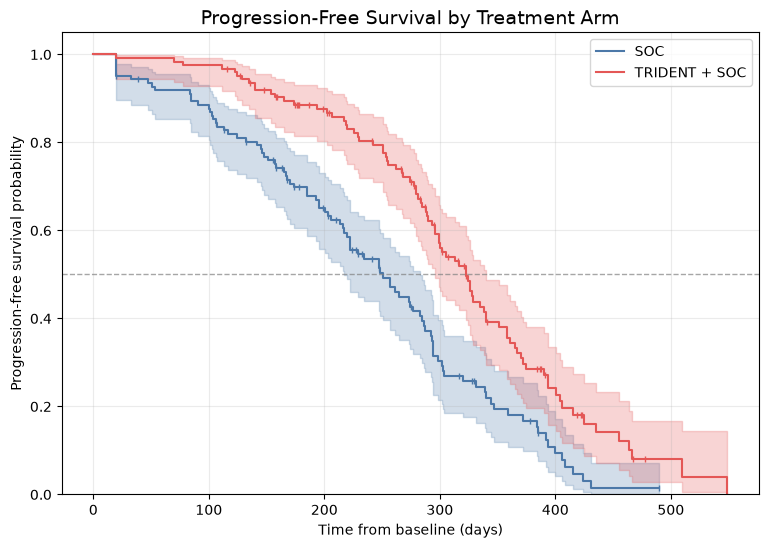

In [23]:
# Objective: Plot treatment-specific Kaplan–Meier PFS curves.

# Create one figure and axes for both treatment arms.
pfs_by_arm_figure, pfs_by_arm_ax = plt.subplots(
    figsize=(9, 6)
)

# Plot the SOC curve.
pfs_km_soc.plot_survival_function(
    ax=pfs_by_arm_ax,
    ci_show=True,
    show_censors=True,
    color="#4C78A8",
    censor_styles={
        "marker": "|",
        "ms": 5,
    },
)

# Plot the TRIDENT + SOC curve on the same axes.
pfs_km_trident.plot_survival_function(
    ax=pfs_by_arm_ax,
    ci_show=True,
    show_censors=True,
    color="#E45756",
    censor_styles={
        "marker": "|",
        "ms": 5,
    },
)

# Add a horizontal reference line at 50% survival.
pfs_by_arm_ax.axhline(
    y=0.50,
    color="gray",
    linestyle="--",
    linewidth=1,
    alpha=0.7,
)

# Add scientific labels and formatting.
pfs_by_arm_ax.set_title(
    "Progression-Free Survival by Treatment Arm",
    fontsize=14,
)

pfs_by_arm_ax.set_xlabel("Time from baseline (days)")
pfs_by_arm_ax.set_ylabel("Progression-free survival probability")
pfs_by_arm_ax.set_ylim(0, 1.05)
pfs_by_arm_ax.grid(alpha=0.25)

plt.show()

## 13. Log-rank comparison of PFS

### Objective

Formally test whether the complete PFS distributions differ between SOC and 
TRIDENT + SOC.

### Statistical hypotheses

- Null hypothesis: the PFS distributions are the same between treatment arms.
- Alternative hypothesis: the PFS distributions differ between treatment arms.

In [24]:
# Objective: Perform a two-sided log-rank test comparing PFS between treatment arms.

# Import the two-group log-rank test.
from lifelines.statistics import logrank_test

# Compare the complete PFS distributions.
pfs_logrank_result = logrank_test(
    durations_A=pfs_soc_data["pfs_days"],
    durations_B=pfs_trident_data["pfs_days"],
    event_observed_A=pfs_soc_data["pfs_event"],
    event_observed_B=pfs_trident_data["pfs_event"],
)

# Display the key statistical results.
print(
    "Log-rank test statistic:",
    round(pfs_logrank_result.test_statistic, 3),
)

print(
    "Two-sided p-value:",
    round(pfs_logrank_result.p_value, 6),
)

Log-rank test statistic: 19.823
Two-sided p-value: 8e-06


## 14. Treatment-only Cox proportional-hazards model

### Objective

Prepare a numeric treatment indicator for estimating the relative hazard of 
progression or death with TRIDENT + SOC versus SOC.

### Biological hypothesis

TRIDENT + SOC reduces the hazard of progression or death relative to SOC.

### Model

\[
h(t \mid treatment)=h_0(t)\exp(\beta_1 treatment)
\]

where SOC is the reference group.

In [25]:
# Objective: Create and verify the treatment-only PFS Cox modeling dataset.

# Retain only the variables needed for the treatment-only model.
pfs_cox_data = pfs_analysis_data[
    [
        "patient_id",
        "treatment_arm",
        "pfs_days",
        "pfs_event",
    ]
].copy()

# Encode SOC as 0 and TRIDENT + SOC as 1.
pfs_cox_data["treatment_binary"] = (
    pfs_cox_data["treatment_arm"]
    .map(
        {
            "SOC": 0,
            "TRIDENT + SOC": 1,
        }
    )
)

# Verify that every treatment label mapped correctly.
print("Missing treatment encodings:")
print(pfs_cox_data["treatment_binary"].isna().sum())

print("\nTreatment-arm encoding:")
display(
    pd.crosstab(
        pfs_cox_data["treatment_arm"],
        pfs_cox_data["treatment_binary"],
    )
)

print("\nCox modeling dataset shape:")
print(pfs_cox_data.shape)

Missing treatment encodings:
0

Treatment-arm encoding:


treatment_binary,0,1
treatment_arm,,
SOC,124,0
TRIDENT + SOC,0,125



Cox modeling dataset shape:
(249, 5)


In [26]:
# Objective: Fit a treatment-only Cox model for progression-free survival.

# Import the Cox proportional-hazards estimator.
from lifelines import CoxPHFitter

# Keep only the numeric variables required by the model.
# Patient ID and text treatment labels are not predictors.
pfs_cox_model_data = pfs_cox_data[
    [
        "pfs_days",
        "pfs_event",
        "treatment_binary",
    ]
].copy()

# Create the unfitted Cox model.
pfs_treatment_cox = CoxPHFitter()

# Fit the model using PFS time and event status.
pfs_treatment_cox.fit(
    pfs_cox_model_data,
    duration_col="pfs_days",
    event_col="pfs_event",
)

# Display the treatment coefficient, hazard ratio, uncertainty, and p-value.
pfs_treatment_cox_results = pfs_treatment_cox.summary[
    [
        "coef",
        "exp(coef)",
        "se(coef)",
        "exp(coef) lower 95%",
        "exp(coef) upper 95%",
        "p",
    ]
].copy()

display(pfs_treatment_cox_results.round(4))

,coef,exp(coef),se(coef),exp(coef) lower 95%,exp(coef) upper 95%,p
covariate,,,,,,
treatment_binary,-0.6644,0.5146,0.1518,0.3822,0.6929,0.0


In [27]:
# Objective: Display the Cox treatment p-value without rounding it to zero.

# Extract the precise Wald-test p-value.
pfs_treatment_p_value = pfs_treatment_cox.summary.loc[
    "treatment_binary",
    "p",
]

print(
    "Precise Cox treatment p-value:",
    f"{pfs_treatment_p_value:.8g}",
)

Precise Cox treatment p-value: 1.2055186e-05


## 15. Proportional-hazards assumption check

### Objective

Test whether the treatment hazard ratio shows evidence of changing systematically 
over follow-up time.

### Statistical hypotheses

- Null hypothesis: the treatment effect satisfies the proportional-hazards assumption.
- Alternative hypothesis: the treatment effect changes over time.

## 15. Proportional-hazards assumption check

### Objective

Test whether the treatment hazard ratio shows evidence of changing systematically 
over follow-up time.

### Statistical hypotheses

- Null hypothesis: the treatment effect satisfies the proportional-hazards assumption.
- Alternative hypothesis: the treatment effect changes over time.

In [28]:
# Objective: Test the proportional-hazards assumption for the treatment effect.

# Import the Schoenfeld-residual proportional-hazards test.
from lifelines.statistics import proportional_hazard_test

# Test whether the treatment coefficient changes systematically over time.
pfs_ph_test = proportional_hazard_test(
    pfs_treatment_cox,
    pfs_cox_model_data,
    time_transform="rank",
)

# Display the test statistic and p-value.
pfs_ph_test_results = pfs_ph_test.summary.copy()

display(pfs_ph_test_results.round(4))

,test_statistic,p,-log2(p)
treatment_binary,4.1338,0.042,4.5723


### Visual proportional-hazards diagnostic

#### Objective

Inspect whether the treatment Schoenfeld residuals show a systematic relationship 
with follow-up time.

#### Diagnostic question

Does the estimated treatment effect remain reasonably stable, or does it change 
systematically during follow-up?


   Bootstrapping lowess lines. May take a moment...

The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.





1. Variable 'treatment_binary' failed the non-proportional test: p-value is 0.0420.

   Advice: with so few unique values (only 2), you can include `strata=['treatment_binary', ...]` in
the call in `.fit`. See documentation in link [E] below.

---
[A]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html
[B]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Bin-variable-and-stratify-on-it
[C]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Introduce-time-varying-covariates
[D]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Modify-the-functional-form
[E]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Stratification



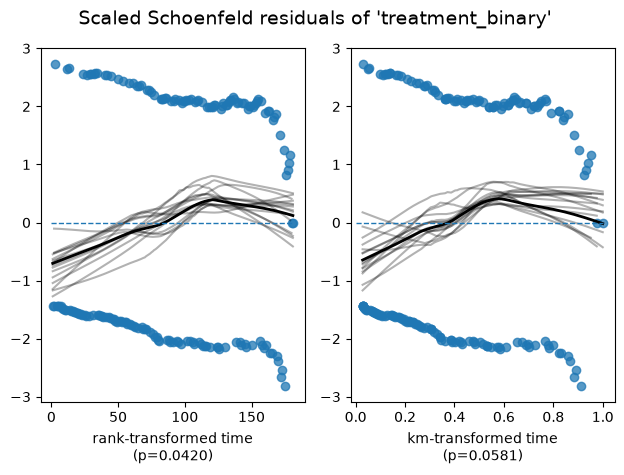

In [29]:
# Objective: Visually inspect the treatment proportional-hazards diagnostic.

# Run Lifelines' diagnostic using the fitted Cox model
# and the same data used to fit it.
pfs_ph_diagnostic_output = pfs_treatment_cox.check_assumptions(
    pfs_cox_model_data,
    p_value_threshold=0.05,
    show_plots=True,
)

## 16. Restricted mean PFS analysis

### Objective

Inspect the numbers at risk at candidate restriction times before selecting the 
common follow-up limit for RMST.

### Biological question

Over a clinically meaningful period with adequate follow-up in both arms, how many 
progression-free days does TRIDENT + SOC provide compared with SOC?

In [30]:
# Objective: Count patients at risk at candidate RMST restriction times.

# Define candidate times in days.
rmst_candidate_times = [0, 180, 365, 450]

# Store one row for each treatment arm and candidate time.
rmst_risk_rows = []

for treatment_arm, arm_data in [
    ("SOC", pfs_soc_data),
    ("TRIDENT + SOC", pfs_trident_data),
]:
    for time_day in rmst_candidate_times:

        # A patient is at risk immediately before this time when their
        # observed PFS duration is at least as long as the selected time.
        number_at_risk = (
            arm_data["pfs_days"] >= time_day
        ).sum()

        rmst_risk_rows.append(
            {
                "treatment_arm": treatment_arm,
                "time_days": time_day,
                "number_at_risk": number_at_risk,
            }
        )

# Convert the stored rows into a clear table.
rmst_numbers_at_risk = pd.DataFrame(rmst_risk_rows)

# Display treatment arms as rows and candidate times as columns.
rmst_numbers_at_risk_table = rmst_numbers_at_risk.pivot(
    index="treatment_arm",
    columns="time_days",
    values="number_at_risk",
)

display(rmst_numbers_at_risk_table)

time_days,0,180,365,450
treatment_arm,,,,
SOC,124,76,14,1
TRIDENT + SOC,125,101,29,7


In [31]:
# Objective: Calculate treatment-specific RMST through 365 days.

# Import the RMST calculation function.
from lifelines.utils import restricted_mean_survival_time

# Select the common, clinically meaningful restriction time.
rmst_tau_days = 365

# Calculate the area under each PFS curve through day 365.
soc_rmst_365 = restricted_mean_survival_time(
    pfs_km_soc,
    t=rmst_tau_days,
)

trident_rmst_365 = restricted_mean_survival_time(
    pfs_km_trident,
    t=rmst_tau_days,
)

# Calculate the absolute treatment difference.
rmst_difference_365 = trident_rmst_365 - soc_rmst_365

# Create a simple point-estimate summary.
pfs_rmst_point_estimates = pd.DataFrame(
    {
        "restriction_time_days": [rmst_tau_days],
        "soc_rmst_days": [soc_rmst_365],
        "trident_rmst_days": [trident_rmst_365],
        "rmst_difference_days": [rmst_difference_365],
    }
)

display(pfs_rmst_point_estimates.round(1))

,restriction_time_days,soc_rmst_days,trident_rmst_days,rmst_difference_days
0,365,235.3,296.8,61.4


# Objective: Estimate a bootstrap 95% CI for the 365-day RMST difference.

import numpy as np

# Make the bootstrap reproducible.
rmst_rng = np.random.default_rng(2026)

# Choose the number of bootstrap repetitions.
rmst_bootstrap_repetitions = 2000

# Store one RMST difference from each bootstrap sample.
rmst_bootstrap_differences = []

for bootstrap_iteration in range(rmst_bootstrap_repetitions):

    # Resample SOC patients with replacement.
    soc_bootstrap_indices = rmst_rng.integers(
        low=0,
        high=len(pfs_soc_data),
        size=len(pfs_soc_data),
    )

    soc_bootstrap_sample = pfs_soc_data.iloc[
        soc_bootstrap_indices
    ]

    # Resample TRIDENT + SOC patients with replacement.
    trident_bootstrap_indices = rmst_rng.integers(
        low=0,
        high=len(pfs_trident_data),
        size=len(pfs_trident_data),
    )

    trident_bootstrap_sample = pfs_trident_data.iloc[
        trident_bootstrap_indices
    ]

    # Fit the two bootstrap Kaplan–Meier curves.
    soc_bootstrap_km = KaplanMeierFitter().fit(
        soc_bootstrap_sample["pfs_days"],
        event_observed=soc_bootstrap_sample["pfs_event"],
    )

    trident_bootstrap_km = KaplanMeierFitter().fit(
        trident_bootstrap_sample["pfs_days"],
        event_observed=trident_bootstrap_sample["pfs_event"],
    )

    # Calculate and store the bootstrap RMST difference.
    bootstrap_difference = (
        restricted_mean_survival_time(
            trident_bootstrap_km,
            t=rmst_tau_days,
        )
        - restricted_mean_survival_time(
            soc_bootstrap_km,
            t=rmst_tau_days,
        )
    )

    rmst_bootstrap_differences.append(
        bootstrap_difference
    )

# Convert the stored differences into a numeric array.
rmst_bootstrap_differences = np.array(
    rmst_bootstrap_differences
)

# Calculate the percentile 95% confidence interval.
rmst_difference_ci_lower = np.percentile(
    rmst_bootstrap_differences,
    2.5,
)

rmst_difference_ci_upper = np.percentile(
    rmst_bootstrap_differences,
    97.5,
)

print("RMST difference:", round(rmst_difference_365, 1), "days")
print(
    "Bootstrap 95% CI:",
    round(rmst_difference_ci_lower, 1),
    "to",
    round(rmst_difference_ci_upper, 1),
    "days",
)

## 17. Overall survival

### Objective

Estimate overall survival across the complete valid OS analysis population before 
comparing treatment arms.

### Biological question

How long do patients in the overall TRIDENT-201 population remain alive after 
baseline?

### Endpoint definition

Overall survival measures time from baseline until death from any cause. Patients 
who are alive at their last known follow-up are censored.

### Statistical hypothesis

No between-group hypothesis is tested in this initial descriptive analysis.

In [32]:
# Objective: Fit the overall Kaplan–Meier estimator for overall survival.

# Create an unfitted Kaplan–Meier estimator for overall survival.
os_km_overall = KaplanMeierFitter()

# Fit the estimator using OS time and death status.
os_km_overall.fit(
    durations=os_analysis_data["os_days"],
    event_observed=os_analysis_data["os_event"],
    label="Overall OS",
)

# Retrieve the estimated median OS.
overall_median_os_days = os_km_overall.median_survival_time_

print("OS analysis population:", len(os_analysis_data))
print("Observed deaths:", int(os_analysis_data["os_event"].sum()))
print(
    "Censored OS observations:",
    int((os_analysis_data["os_event"] == 0).sum()),
)
print("Estimated median OS:", overall_median_os_days, "days")

OS analysis population: 250
Observed deaths: 123
Censored OS observations: 127
Estimated median OS: 564.0 days


In [33]:
# Objective: Calculate the 95% confidence interval for overall median OS.

# Convert the OS survival-curve confidence limits
# into confidence limits for median OS.
overall_median_os_ci = median_survival_times(
    os_km_overall.confidence_interval_
)

print("Estimated median OS:", overall_median_os_days, "days")
print("\n95% confidence interval for median OS:")
display(overall_median_os_ci)

Estimated median OS: 564.0 days

95% confidence interval for median OS:


,Overall OS_lower_0.95,Overall OS_upper_0.95
0.5,535.0,602.0


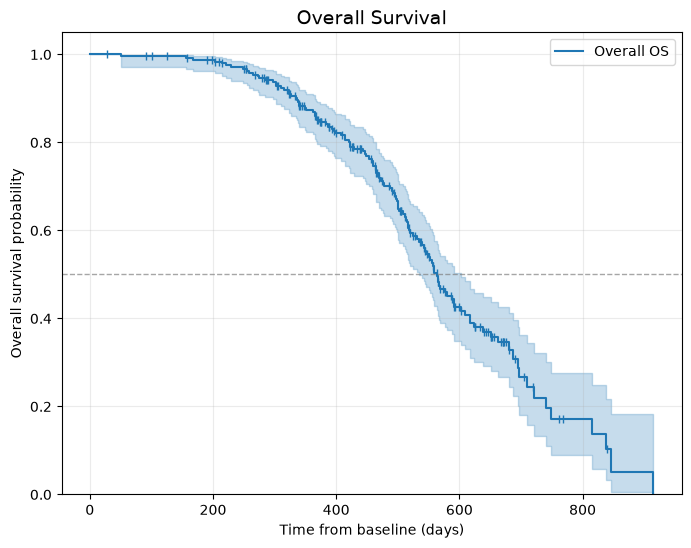

In [34]:
# Objective: Plot the overall OS Kaplan–Meier curve with uncertainty and censoring.

# Plot the fitted overall OS estimator.
os_overall_ax = os_km_overall.plot_survival_function(
    ci_show=True,
    show_censors=True,
    censor_styles={
        "marker": "|",
        "ms": 6,
    },
    figsize=(8, 6),
)

# Add a horizontal reference line for median survival.
os_overall_ax.axhline(
    y=0.50,
    color="gray",
    linestyle="--",
    linewidth=1,
    alpha=0.7,
)

# Add clear scientific labels.
os_overall_ax.set_title(
    "Overall Survival",
    fontsize=14,
)

os_overall_ax.set_xlabel("Time from baseline (days)")
os_overall_ax.set_ylabel("Overall survival probability")
os_overall_ax.set_ylim(0, 1.05)
os_overall_ax.grid(alpha=0.25)

plt.show()

In [36]:
# Display all available OS columns
print("OS analysis columns:")
print(os_analysis_data.columns.tolist())

# Confirm the exact treatment-arm labels
print("\nTreatment-arm values:")
print(os_analysis_data["treatment_arm"].value_counts(dropna=False))

OS analysis columns:
['patient_id', 'treatment_arm', 'age', 'sex', 'disease_stage', 'ecog_status', 'smoking_status', 'histology', 'best_overall_response', 'pfs_days', 'pfs_event', 'os_days', 'os_event', 'study_site', 'enrollment_date']

Treatment-arm values:
treatment_arm
TRIDENT + SOC    125
SOC              125
Name: count, dtype: int64


In [37]:
# Create treatment-specific OS datasets using the confirmed labels
os_soc_data = os_analysis_data.loc[
    os_analysis_data["treatment_arm"] == "SOC"
].copy()

os_trident_data = os_analysis_data.loc[
    os_analysis_data["treatment_arm"] == "TRIDENT + SOC"
].copy()

# Verify the OS outcome counts in each treatment arm
print(
    os_analysis_data.groupby("treatment_arm")["os_event"]
    .agg(
        patients="size",
        deaths="sum",
        censored=lambda events: (events == 0).sum()
    )
)

               patients  deaths  censored
treatment_arm                            
SOC                 125      59        66
TRIDENT + SOC       125      64        61


In [38]:
# Fit the SOC overall-survival Kaplan–Meier estimator
os_km_soc = KaplanMeierFitter(label="SOC")
os_km_soc.fit(
    durations=os_soc_data["os_days"],
    event_observed=os_soc_data["os_event"]
)

# Fit the TRIDENT + SOC overall-survival Kaplan–Meier estimator
os_km_trident = KaplanMeierFitter(label="TRIDENT + SOC")
os_km_trident.fit(
    durations=os_trident_data["os_days"],
    event_observed=os_trident_data["os_event"]
)

# Confirm that both estimators were fitted to 125 patients
print("SOC observations fitted:", os_km_soc.event_table["entrance"].sum())
print(
    "TRIDENT + SOC observations fitted:",
    os_km_trident.event_table["entrance"].sum()
)

SOC observations fitted: 125
TRIDENT + SOC observations fitted: 125


In [39]:
# Import the function used to obtain median-survival confidence intervals
from lifelines.utils import median_survival_times

# Calculate median OS and 95% CI for SOC
soc_median_os_days = os_km_soc.median_survival_time_
soc_median_os_ci = median_survival_times(
    os_km_soc.confidence_interval_
)

# Calculate median OS and 95% CI for TRIDENT + SOC
trident_median_os_days = os_km_trident.median_survival_time_
trident_median_os_ci = median_survival_times(
    os_km_trident.confidence_interval_
)

# Display the treatment-specific estimates
print("SOC median OS:", soc_median_os_days, "days")
print("SOC median OS 95% CI:")
display(soc_median_os_ci)

print("\nTRIDENT + SOC median OS:", trident_median_os_days, "days")
print("TRIDENT + SOC median OS 95% CI:")
display(trident_median_os_ci)

SOC median OS: 553.0 days
SOC median OS 95% CI:


,SOC_lower_0.95,SOC_upper_0.95
0.5,502.0,617.0



TRIDENT + SOC median OS: 567.0 days
TRIDENT + SOC median OS 95% CI:


,TRIDENT + SOC_lower_0.95,TRIDENT + SOC_upper_0.95
0.5,535.0,624.0


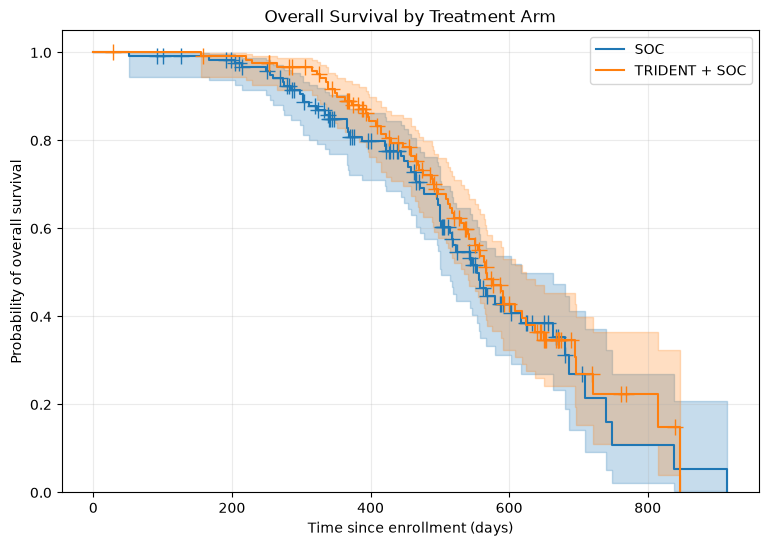

In [40]:
# Create a figure for the treatment-specific OS curves
os_treatment_fig, os_treatment_ax = plt.subplots(figsize=(9, 6))

# Plot SOC overall survival
os_km_soc.plot_survival_function(
    ax=os_treatment_ax,
    ci_show=True,
    show_censors=True
)

# Plot TRIDENT + SOC overall survival
os_km_trident.plot_survival_function(
    ax=os_treatment_ax,
    ci_show=True,
    show_censors=True
)

# Add clear clinical labels
os_treatment_ax.set_title("Overall Survival by Treatment Arm")
os_treatment_ax.set_xlabel("Time since enrollment (days)")
os_treatment_ax.set_ylabel("Probability of overall survival")
os_treatment_ax.set_ylim(0, 1.05)
os_treatment_ax.grid(alpha=0.25)

plt.show()

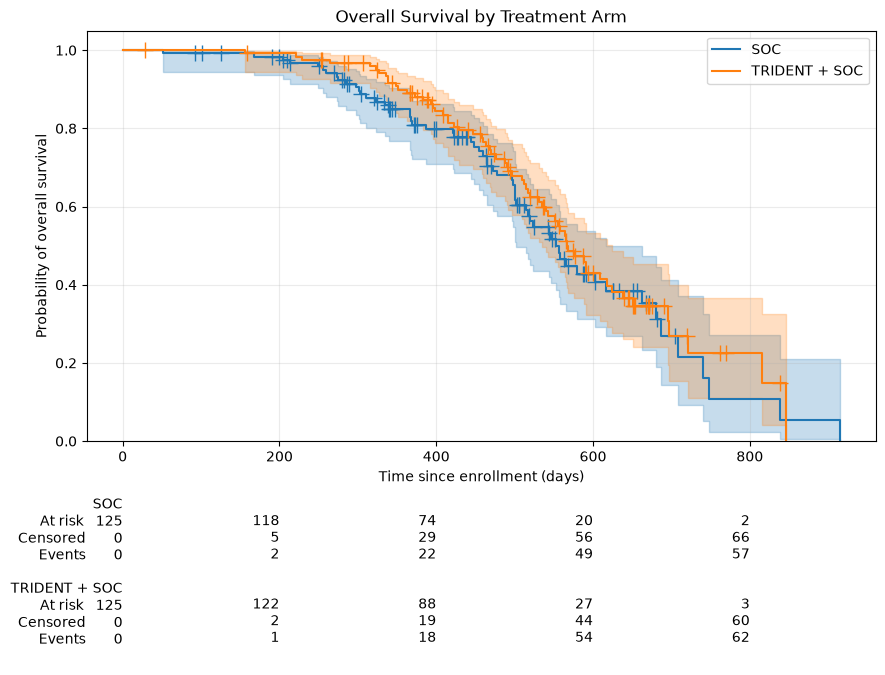

In [41]:
# Import the function for adding a numbers-at-risk table
from lifelines.plotting import add_at_risk_counts

# Create the OS plot
os_treatment_risk_fig, os_treatment_risk_ax = plt.subplots(figsize=(9, 7))

os_km_soc.plot_survival_function(
    ax=os_treatment_risk_ax,
    ci_show=True,
    show_censors=True
)

os_km_trident.plot_survival_function(
    ax=os_treatment_risk_ax,
    ci_show=True,
    show_censors=True
)

# Add clinical labels
os_treatment_risk_ax.set_title("Overall Survival by Treatment Arm")
os_treatment_risk_ax.set_xlabel("Time since enrollment (days)")
os_treatment_risk_ax.set_ylabel("Probability of overall survival")
os_treatment_risk_ax.set_ylim(0, 1.05)
os_treatment_risk_ax.grid(alpha=0.25)

# Show how many patients remain under observation over time
add_at_risk_counts(
    os_km_soc,
    os_km_trident,
    ax=os_treatment_risk_ax
)

plt.tight_layout()
plt.show()

In [42]:
# Import the two-group log-rank test
from lifelines.statistics import logrank_test

# Compare OS between the two treatment arms
os_logrank_result = logrank_test(
    os_soc_data["os_days"],
    os_trident_data["os_days"],
    event_observed_A=os_soc_data["os_event"],
    event_observed_B=os_trident_data["os_event"]
)

# Display the test statistic and p-value
print("OS log-rank statistic:", round(os_logrank_result.test_statistic, 4))
print("OS log-rank p-value:", round(os_logrank_result.p_value, 6))

OS log-rank statistic: 0.5988
OS log-rank p-value: 0.439049


In [43]:
# Keep only the columns needed for the treatment-only OS Cox model
os_cox_data = os_analysis_data[
    ["os_days", "os_event", "treatment_arm"]
].copy()

# Encode SOC as 0 and TRIDENT + SOC as 1
os_cox_data["treatment_binary"] = (
    os_cox_data["treatment_arm"] == "TRIDENT + SOC"
).astype(int)

# Verify the treatment encoding
print(
    pd.crosstab(
        os_cox_data["treatment_arm"],
        os_cox_data["treatment_binary"]
    )
)





treatment_binary    0    1
treatment_arm             
SOC               125    0
TRIDENT + SOC       0  125


In [44]:
# Import the Cox proportional-hazards model
from lifelines import CoxPHFitter

# Create and fit the treatment-only OS Cox model
os_cox_model = CoxPHFitter()
os_cox_model.fit(
    os_cox_data[["os_days", "os_event", "treatment_binary"]],
    duration_col="os_days",
    event_col="os_event"
)

# Display the model results
display(os_cox_model.summary)

,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
treatment_binary,-0.140771,0.868688,0.18162,-0.49674,0.215198,0.608511,1.240107,0.0,-0.775087,0.438288,1.190048


In [45]:
# Import the Schoenfeld-residual proportional-hazards test
from lifelines.statistics import proportional_hazard_test

# Test whether the treatment hazard ratio changes over time
os_ph_test_km = proportional_hazard_test(
    os_cox_model,
    os_cox_data[["os_days", "os_event", "treatment_binary"]],
    time_transform="km"
)

os_ph_test_rank = proportional_hazard_test(
    os_cox_model,
    os_cox_data[["os_days", "os_event", "treatment_binary"]],
    time_transform="rank"
)

# Display both diagnostic results
print("KM time transformation:")
display(os_ph_test_km.summary)

print("\nRank time transformation:")
display(os_ph_test_rank.summary)

KM time transformation:


,test_statistic,p,-log2(p)
treatment_binary,0.46029,0.497489,1.007265



Rank time transformation:


,test_statistic,p,-log2(p)
treatment_binary,0.778644,0.377556,1.405237


In [46]:
# Combine the verified treatment-specific OS results
os_arm_summary = pd.DataFrame({
    "treatment_arm": ["SOC", "TRIDENT + SOC"],
    "n_patients": [len(os_soc_data), len(os_trident_data)],
    "deaths": [
        int(os_soc_data["os_event"].sum()),
        int(os_trident_data["os_event"].sum())
    ],
    "censored": [
        int((os_soc_data["os_event"] == 0).sum()),
        int((os_trident_data["os_event"] == 0).sum())
    ],
    "median_os_days": [soc_median_os_days, trident_median_os_days],
    "median_ci_lower_days": [
        soc_median_os_ci.iloc[0, 0],
        trident_median_os_ci.iloc[0, 0]
    ],
    "median_ci_upper_days": [
        soc_median_os_ci.iloc[0, 1],
        trident_median_os_ci.iloc[0, 1]
    ]
})

display(os_arm_summary)

,treatment_arm,n_patients,deaths,censored,median_os_days,median_ci_lower_days,median_ci_upper_days
0,SOC,125,59,66,553.0,502.0,617.0
1,TRIDENT + SOC,125,64,61,567.0,535.0,624.0


In [47]:
# Extract the verified Cox-model treatment results
os_cox_treatment_result = os_cox_model.summary.loc["treatment_binary"]

# Combine the OS treatment-comparison results
os_comparison_summary = pd.DataFrame({
    "comparison": ["TRIDENT + SOC vs SOC"],
    "logrank_statistic": [os_logrank_result.test_statistic],
    "logrank_p_value": [os_logrank_result.p_value],
    "hazard_ratio": [os_cox_treatment_result["exp(coef)"]],
    "hr_ci_lower": [os_cox_treatment_result["exp(coef) lower 95%"]],
    "hr_ci_upper": [os_cox_treatment_result["exp(coef) upper 95%"]],
    "cox_p_value": [os_cox_treatment_result["p"]],
    "ph_km_p_value": [
        os_ph_test_km.summary.loc["treatment_binary", "p"]
    ],
    "ph_rank_p_value": [
        os_ph_test_rank.summary.loc["treatment_binary", "p"]
    ]
})

# Display a readable version without changing the stored precision
display(os_comparison_summary.round(4))

,comparison,logrank_statistic,logrank_p_value,hazard_ratio,hr_ci_lower,hr_ci_upper,cox_p_value,ph_km_p_value,ph_rank_p_value
0,TRIDENT + SOC vs SOC,0.5988,0.439,0.8687,0.6085,1.2401,0.4383,0.4975,0.3776


In [48]:
# Import Path for safe inspection of project folders
from pathlib import Path

# Show where the notebook is currently running
print("Current working directory:")
print(Path.cwd())

# Show existing directories in the parent project folder
print("\nExisting directories one level above:")
print(sorted(path.name for path in Path("..").iterdir() if path.is_dir()))

Current working directory:
/Users/goncabulbul/Documents/GitHub/TRIDENT-201-translational-analysis/notebooks

Existing directories one level above:
['.git', 'data', 'figures', 'notebooks', 'results']


In [49]:
# Define the output paths for the verified OS result tables
os_arm_summary_path = Path("../results/os_by_treatment_summary.csv")
os_comparison_summary_path = Path("../results/os_treatment_comparison_results.csv")

# Save full-precision numeric results
os_arm_summary.to_csv(os_arm_summary_path, index=False)
os_comparison_summary.to_csv(os_comparison_summary_path, index=False)

# Confirm that both files were created successfully
print("Arm summary saved:", os_arm_summary_path.exists())
print("Comparison results saved:", os_comparison_summary_path.exists())
print("\nArm summary path:", os_arm_summary_path)
print("Comparison results path:", os_comparison_summary_path)

Arm summary saved: True
Comparison results saved: True

Arm summary path: ../results/os_by_treatment_summary.csv
Comparison results path: ../results/os_treatment_comparison_results.csv


In [50]:
# Define the output path for the verified OS figure
os_treatment_figure_path = Path(
    "../figures/os_kaplan_meier_by_treatment.png"
)

# Save at high resolution with the full risk table included
os_treatment_risk_fig.savefig(
    os_treatment_figure_path,
    dpi=300,
    bbox_inches="tight"
)

# Confirm that the figure was saved successfully
print("OS figure saved:", os_treatment_figure_path.exists())
print("OS figure path:", os_treatment_figure_path)

OS figure saved: True
OS figure path: ../figures/os_kaplan_meier_by_treatment.png


## Survival-analysis conclusions

### Progression-free survival

Among 249 PFS-evaluable patients, median PFS was 251 days with SOC and 323 days with TRIDENT + SOC, corresponding to an observed median difference of 72 days. The PFS distributions differed significantly between treatment arms by the log-rank test (p = 0.000008). In a treatment-only Cox model, TRIDENT + SOC was associated with a 48.5% lower instantaneous hazard of progression or death compared with SOC (HR = 0.515, 95% CI: 0.382–0.693; p = 0.000012).

Schoenfeld-residual diagnostics provided mild, borderline evidence that the PFS treatment hazard ratio may vary over time. The Cox hazard ratio should therefore be interpreted as an average relative treatment effect over follow-up. In a complementary restricted mean survival time analysis through 365 days, patients receiving TRIDENT + SOC experienced an estimated 61.4 additional progression-free days compared with SOC (95% bootstrap CI: 36.0–85.8 days).

### Overall survival

Among 250 OS-evaluable patients, median OS was 553 days with SOC and 567 days with TRIDENT + SOC. The OS distributions did not differ significantly by the log-rank test (p = 0.439). In a treatment-only Cox model, TRIDENT + SOC was associated with an estimated 13.1% lower hazard of death, but the effect was not statistically significant (HR = 0.869, 95% CI: 0.609–1.240; p = 0.438). Schoenfeld-residual diagnostics did not indicate violation of the proportional-hazards assumption.

### Integrated interpretation

TRIDENT + SOC produced a statistically significant and clinically meaningful improvement in PFS, supported by both the Cox and RMST analyses. However, a corresponding improvement in OS was not demonstrated in this dataset. The absence of a statistically significant OS difference should not be interpreted as proof of equivalent survival; the confidence interval remains compatible with both a reduction and an increase in the hazard of death. Potential explanations for the PFS–OS discrepancy include subsequent anticancer therapies, treatment crossover, limited statistical power for OS, follow-up duration, and post-progression disease biology. These possibilities would require additional trial information and should not be asserted as established explanations.

In [52]:
# Check the completed endpoint-specific analyses and saved outputs
survival_integrity_checks = pd.Series({
    "pfs_population_is_249":
        len(pfs_analysis_data) == 249,

    "pfs_has_no_negative_durations":
        (pfs_analysis_data["pfs_days"] >= 0).all(),

    "pfs_has_no_missing_endpoint_values":
        pfs_analysis_data[["pfs_days", "pfs_event"]].notna().all().all(),

    "os_population_is_250":
        len(os_analysis_data) == 250,

    "os_unique_patients_is_250":
        os_analysis_data["patient_id"].nunique() == 250,

    "os_deaths_total_123":
        int(os_analysis_data["os_event"].sum()) == 123,

    "os_censored_total_127":
        int((os_analysis_data["os_event"] == 0).sum()) == 127,

    "os_has_no_missing_endpoint_values":
        os_analysis_data[["os_days", "os_event"]].notna().all().all(),

    "os_arms_are_balanced":
        os_analysis_data["treatment_arm"].value_counts().eq(125).all(),

    "os_arm_summary_file_exists":
        os_arm_summary_path.exists(),

    "os_comparison_file_exists":
        os_comparison_summary_path.exists(),

    "os_figure_file_exists":
        os_treatment_figure_path.exists()
})

display(survival_integrity_checks)

pfs_population_is_249                 True
pfs_has_no_negative_durations         True
pfs_has_no_missing_endpoint_values    True
os_population_is_250                  True
os_unique_patients_is_250             True
os_deaths_total_123                   True
os_censored_total_127                 True
os_has_no_missing_endpoint_values     True
os_arms_are_balanced                  True
os_arm_summary_file_exists            True
os_comparison_file_exists             True
os_figure_file_exists                 True
dtype: bool